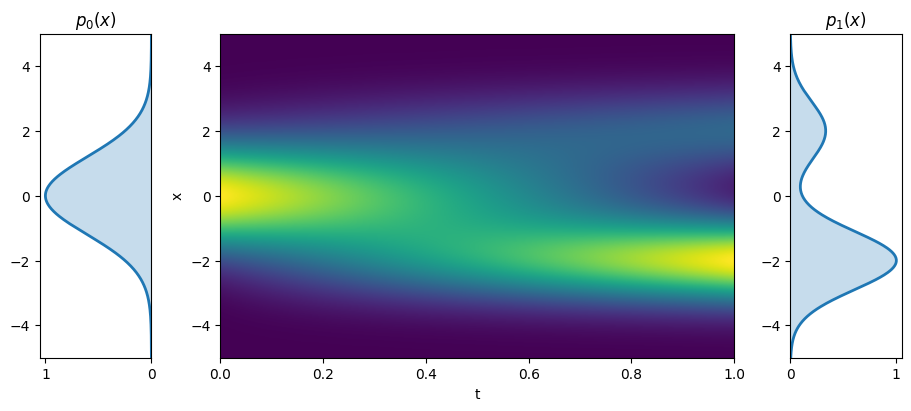

In [3]:
# Visualising a probability path p_t(x) interpolating between two 1D distributions.
#
# p0 = single Gaussian 
# p1 = mixture of two Gaussians 
# p_t = (1-t)*p0 + t*p1  
#


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def normal_pdf(x, mu, sigma):
    """Standard Gaussian."""
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def p0(x):
    """Source distribution."""
    return normal_pdf(x, mu=0.0, sigma=1.2)


def p1(x):
    """Target distribution."""
    w = 0.75
    return w * normal_pdf(x, mu=-2, sigma=0.9) + (1 - w) * normal_pdf(x, mu=2, sigma=0.9)


def p_t(t, x):
    """Interpolated density at time t."""
    return (1.0 - t) * p0(x) + t * p1(x)


def make_plot():
    xs = np.linspace(-5, 5, 400)
    ts = np.linspace(0, 1, 300)
    
    P = np.stack([p_t(t, xs) for t in ts], axis=1)

    pL = P[:, 0]
    pR = P[:, -1]
    pL = pL / (pL.max() + 1e-12)
    pR = pR / (pR.max() + 1e-12)

    fig = plt.figure(figsize=(9, 4), constrained_layout=True)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.3, 6.0, 1.3], wspace=0.05)

    axL = fig.add_subplot(gs[0, 0])
    axM = fig.add_subplot(gs[0, 1], sharey=axL)
    axR = fig.add_subplot(gs[0, 2], sharey=axL)

    im = axM.imshow(
        P,
        origin="lower",
        aspect="auto",
        extent=[ts[0], ts[-1], xs[0], xs[-1]],
        cmap="viridis",
        interpolation="bilinear",
    )
    axM.set_xlabel("t")
    axM.set_ylabel("x")


    axL.fill_betweenx(xs, 0, pL, alpha=0.25)
    axL.plot(pL, xs, lw=2)
    axL.set_title(r"$p_0(x)$")
    #axL.set_xlabel("density")
    axL.invert_xaxis()  
    axL.set_xlim(1.05, 0)


    axR.fill_betweenx(xs, 0, pR, alpha=0.25)
    axR.plot(pR, xs, lw=2)
    axR.set_title(r"$p_1(x)$")
    #axR.set_xlabel("density")
    axR.set_xlim(0, 1.05)

    plt.show()


if __name__ == "__main__":
    make_plot()